# Projeto de Análise de Churn

Churn representa a saída de clientes de um serviço ou empresa em determinado período. Esse indicador é fundamental para negócios que dependem de retenção, pois a perda de clientes impacta diretamente a receita e o crescimento da organização.

Neste projeto, aplicamos técnicas de Análise de Dados e Machine Learning para prever quais clientes possuem maior probabilidade de evasão. Foram realizadas etapas de preparação dos dados, modelagem com algoritmos de classificação (como Regressão Logística e Random Forest) e avaliação de desempenho utilizando métricas adequadas, como ROC-AUC.

O objetivo é compreender os fatores que influenciam o churn e demonstrar, na prática, como a Ciência de Dados pode apoiar decisões estratégicas.

## Importando o arquivo de dataset do meu computador

In [1]:
from google.colab import files
import pandas as pd

upload_de_arquivos = files.upload()

df = pd.read_csv('Churn_Modelling.csv')

df.head(10)

Saving Churn_Modelling.csv to Churn_Modelling.csv


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [2]:
df.shape

(10000, 14)

In [3]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

Através do comando acima foi possível notar a dimensão do dataset. Ele está agrupado por 10.000 linhas e 14 colunas.

Com "df.head(10)" foi possível enxergar quais colunas o dataset traz para participação de informações relevantes. As colunas são:
- RowNumber
- CustomerId
- Surname
- CreditScore
- Geography
- Gender
- Age
- Tenure
- Balance
- NumOfProducts
- HasCrCard
- IsActiveMember
- EstimatedSalary
- Exited

## Verificação de dados duplicados

In [4]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


## Verificação de dados nulos

In [5]:
df.isnull()  #ou df.isna()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


Aparentemente, o comando acima gerou linhas com valores indicadores de "False" para dados nulos, significa que as colunas estão preenchidas corretamente.

In [6]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


A soma de todos os valores nulos em cada coluna foi igual a 0, reforçando, assim, que a base de dados não possui valores nulos.

## Verificação de valores nas colunas

In [7]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


In [8]:
df[['CustomerId', 'Surname','Gender']].head(12)

,CustomerId,Surname,Gender
0,15634602,Hargrave,Female
1,15647311,Hill,Female
2,15619304,Onio,Female
3,15701354,Boni,Female
4,15737888,Mitchell,Female
5,15574012,Chu,Male
6,15592531,Bartlett,Male
7,15656148,Obinna,Female
8,15792365,He,Male
9,15592389,H?,Male


In [9]:
df[['Surname', 'IsActiveMember']].head(12)

,Surname,IsActiveMember
0,Hargrave,1
1,Hill,1
2,Onio,0
3,Boni,0
4,Mitchell,1
5,Chu,0
6,Bartlett,1
7,Obinna,0
8,He,1
9,H?,1


In [10]:
df[['Surname', 'Exited']].head(12)

,Surname,Exited
0,Hargrave,1
1,Hill,0
2,Onio,1
3,Boni,0
4,Mitchell,0
5,Chu,1
6,Bartlett,0
7,Obinna,1
8,He,0
9,H?,0


## Início à Análise de dados

Nesta etapa, realizamos a análise exploratória dos dados (EDA) com o objetivo de compreender os fatores relacionados à evasão de clientes (churn). Utilizando Python e bibliotecas como Pandas, Matplotlib e Seaborn, investigamos a distribuição das variáveis, possíveis correlações e padrões comportamentais associados ao cancelamento do serviço.

A análise de dados é fundamental para identificar tendências, tratar inconsistências e preparar a base para a construção de modelos preditivos. A partir dessa exploração inicial, torna-se possível gerar insights estratégicos e estruturar uma modelagem mais eficiente para prever a saída de clientes.

### Verificando a estimativa de salário por país/região

In [11]:
df.groupby("Geography")["EstimatedSalary"].sum()

,EstimatedSalary
Geography,
France,5.008945e+08
Germany,2.536936e+08
Spain,2.463143e+08


Foi realizada uma agregação dos dados utilizando o método groupby, com o objetivo de analisar a soma do salário estimado (EstimatedSalary) por país (Geography). O resultado indica o volume total de renda estimada concentrada em cada região presente na base de dados.

Observa-se que:

- França apresenta o maior volume total de salário estimado, aproximadamente 500 milhões.

- Alemanha e Espanha possuem valores semelhantes, em torno de 250 milhões cada.

Esse resultado pode indicar que a base de clientes possui maior concentração ou maior volume financeiro na França. No entanto, é importante destacar que a soma total pode estar influenciada pela quantidade de clientes em cada país. Portanto, para uma análise mais precisa, recomenda-se também avaliar a média salarial por cliente e a quantidade de clientes por região.

Essa etapa contribui para a compreensão do perfil financeiro dos clientes e pode auxiliar na identificação de padrões relacionados ao churn em diferentes mercados.

### Taxa de churn

In [12]:
df['Exited'].mean()

np.float64(0.2037)

Foi calculada a média da variável Exited, que representa se o cliente deixou a empresa (1) ou permaneceu (0). O resultado obtido foi:

0.2037

Como se trata de uma variável binária, a média corresponde diretamente à proporção de clientes que saíram. Isso significa que aproximadamente 20,37% dos clientes realizaram churn, enquanto cerca de 79,63% permaneceram na base.

Esse resultado indica que o conjunto de dados apresenta desbalanceamento de classes, uma vez que a quantidade de clientes que permaneceram é significativamente maior do que a quantidade de clientes que saíram.

Esse fator é relevante para a modelagem preditiva, pois pode influenciar o desempenho dos algoritmos. Por esse motivo, métricas como ROC-AUC, Recall e F1-score tornam-se mais apropriadas do que apenas a acurácia na avaliação do modelo.

Essa análise inicial é fundamental para compreender o comportamento geral da base e orientar as decisões nas etapas seguintes do projeto.

### Pessoas que saíram por País/Região

In [13]:
df.groupby("Geography")["Exited"].mean().sort_values(ascending=False) * 100

,Exited
Geography,
Germany,32.443204
Spain,16.673395
France,16.154767


Foi calculada a média da variável Exited agrupada por país (Geography), multiplicada por 100 para representar o resultado em percentual. Como Exited é uma variável binária (0 = permaneceu, 1 = saiu), sua média corresponde diretamente à taxa de churn.

Os resultados foram:

- Alemanha: 32,44%

- Espanha: 16,67%

- França: 16,15%

Observa-se que a Alemanha apresenta uma taxa de churn significativamente superior aos demais países, praticamente o dobro da Espanha e da França. Esse resultado indica que clientes alemães possuem maior probabilidade de evasão, o que pode estar relacionado a fatores regionais, perfil financeiro, concorrência ou características específicas desse mercado.

Já Espanha e França apresentam taxas semelhantes, em torno de 16%, sugerindo maior retenção nesses países.

Essa análise é fundamental para decisões estratégicas, pois permite identificar mercados mais críticos e direcionar ações específicas de retenção para regiões com maior risco de churn.

<Axes: xlabel='Geography'>

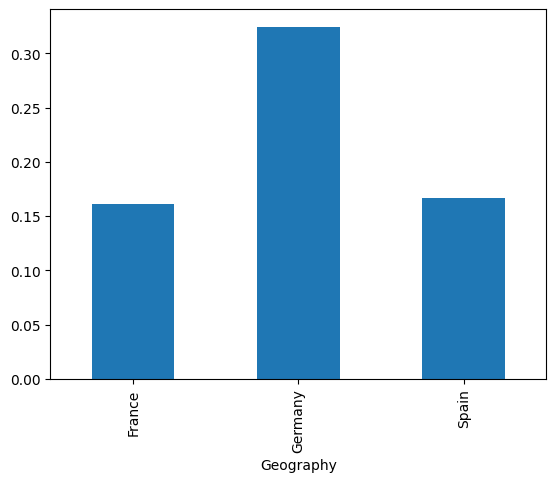

In [14]:
import matplotlib.pyplot as plt

df.groupby('Geography')['Exited'].mean().plot(kind='bar')

Importando a biblioteca de visualizaçaõ de gráficos do Python, é possível acompanhar o crescimento de saídas/desistências de clientes por região/geografia.

Neste caso, a Alemanha lidera o número de desistências (Exited), sendo seguida por Espanha e França logo abaixo.

## Churn por gênero

In [15]:
df.groupby("Gender")["Exited"].mean() * 100

,Exited
Gender,
Female,25.071539
Male,16.455928


Foi calculada a média da variável Exited agrupada por gênero (Gender). Como se trata de uma variável binária (0 = permaneceu, 1 = saiu), sua média representa diretamente a taxa percentual de churn.

Os resultados foram:

- **Feminino**: 25,07%

- **Masculino**: 16,46%

Observa-se que a taxa de evasão entre clientes do gênero feminino é significativamente superior à dos clientes do gênero masculino, apresentando uma diferença de aproximadamente 8,6 pontos percentuais.

Esse resultado indica que, dentro desta base de dados, clientes do gênero feminino possuem maior probabilidade de churn. Essa diferença pode estar relacionada a variáveis comportamentais, perfil de consumo ou outros fatores que deverão ser analisados em conjunto com outras características da base.

Essa análise reforça a importância de considerar variáveis demográficas no processo de modelagem preditiva, uma vez que podem exercer influência relevante na probabilidade de evasão.

<Axes: xlabel='Gender'>

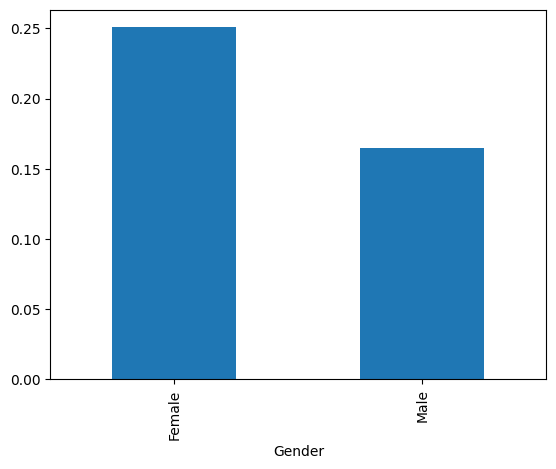

In [16]:
df.groupby('Gender')['Exited'].mean().plot(kind='bar')

Novamente, por meio do gráfico de colunas, é possível ter uma dimensão melhor da distribuição de desistências por gênero. Neste caso, o sexo feminino apresentou um número maior em relação ao sexo masculino.

Não há dados suficientes para estabalecer uma causa para o motivo do sexo feminino estar liderando essa divisão. Porém, é interessante trazer este ponto de vista para o projeto e imaginar como um analista de dados visualiza estas questões dentro de um produto real.

## Idade por Churn

In [17]:
df.groupby("Exited")["Age"].mean()

,Age
Exited,
0,37.408389
1,44.837997


Foi calculada a idade média dos clientes agrupando pela variável Exited.

Os resultados indicam que:

- Clientes que permaneceram possuem idade média de **37,4 anos**.

- Clientes que saíram possuem idade média de **44,8 anos**.

Observa-se que clientes que realizam churn tendem a ser, em média, mais velhos. Esse padrão sugere que a idade pode ser um fator relevante na previsão de evasão e deve ser considerada na modelagem preditiva.

<Axes: xlabel='Age', ylabel='Count'>

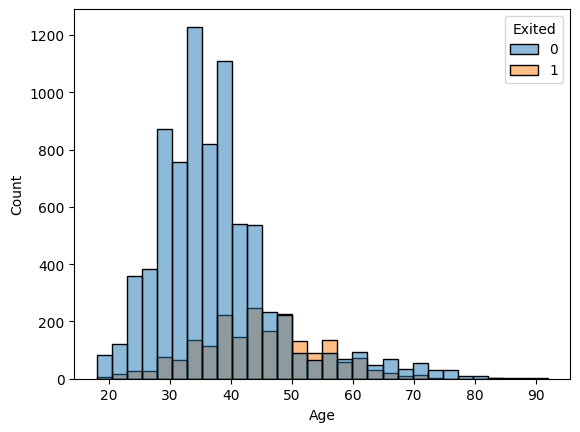

In [18]:
import seaborn as sns

sns.histplot(data=df, x='Age', hue='Exited', bins=30)

## Número de produtos contratados por Churn

In [19]:
df.groupby("NumOfProducts")["Exited"].mean()

,Exited
NumOfProducts,
1,0.277144
2,0.075817
3,0.827068
4,1.000000


Foi analisada a taxa de churn em relação à quantidade de produtos contratados (NumOfProducts). Os resultados indicam:

- **1 produto**: 27,7% de churn

- **2 produtos**: 7,6% de churn

- **3 produtos**: 82,7% de churn

- **4 produtos**: 100% de churn

Observa-se que clientes com 2 produtos apresentam a menor taxa de evasão, sugerindo maior retenção nesse grupo. Por outro lado, clientes com 3 ou 4 produtos possuem taxas extremamente elevadas de churn, o que pode indicar um padrão específico na base ou até um possível desbalanceamento na quantidade de clientes nessas categorias.

Esse resultado mostra que o número de produtos contratados é uma variável altamente relevante para a análise preditiva de churn.

## Saldo vs Churn

In [20]:
df.groupby("Exited")["Balance"].mean()

,Balance
Exited,
0,72745.296779
1,91108.539337


Foi analisado o saldo médio (Balance) dos clientes de acordo com o status de churn.

Os resultados indicam que:

- Clientes que permaneceram possuem saldo médio de aproximadamente **72.745**.

- Clientes que saíram possuem saldo médio de aproximadamente **91.108**.

Observa-se que clientes que realizaram churn apresentam, em média, saldo mais elevado. Esse resultado pode indicar que clientes com maior volume financeiro não estão sendo devidamente retidos, representando um possível risco estratégico para a instituição.

Essa variável pode ter forte influência na modelagem preditiva e merece atenção especial nas análises posteriores.

<Axes: xlabel='Exited', ylabel='Balance'>

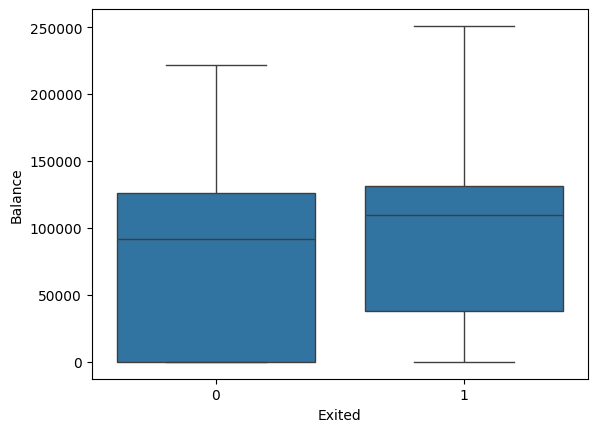

In [21]:
sns.boxplot(x='Exited', y='Balance', data=df)

## Atividades e cartão de crédito

In [22]:
df.groupby("IsActiveMember")["Exited"].mean() * 100

,Exited
IsActiveMember,
0,26.850897
1,14.269074


Foi analisada a taxa de churn considerando a variável IsActiveMember, que indica se o cliente é ativo ou não.

Os resultados mostram que:

- **Clientes inativos (0)**: 26,85% de churn

- **Clientes ativos (1)**: 14,27% de churn

Observa-se que clientes inativos apresentam uma taxa de evasão significativamente maior. Esse resultado sugere que o nível de engajamento do cliente com a instituição está diretamente relacionado à probabilidade de churn.

Assim, a variável de atividade demonstra forte relevância para a análise e para a construção do modelo preditivo, podendo ser um dos principais indicadores de risco de evasão.

In [23]:
df.groupby("HasCrCard")["Exited"].mean() * 100

,Exited
HasCrCard,
0,20.814941
1,20.184266


Foi analisada a taxa de churn com base na variável HasCrCard, que indica se o cliente possui cartão de crédito.

Os resultados mostram que:

- **Sem cartão (0)**: 20,81% de churn

- **Com cartão (1)**: 20,18% de churn

Observa-se que a diferença entre os grupos é mínima, indicando que a posse de cartão de crédito não parece exercer influência significativa sobre a evasão de clientes nesta base de dados.

Esse resultado sugere que essa variável, isoladamente, pode não ser um fator determinante para prever churn, embora ainda possa contribuir em conjunto com outras variáveis no modelo preditivo.

## Análise de Correlação

A correlação mede o grau de relação linear entre duas variáveis, indicando se elas tendem a variar juntas (positivamente), de forma inversa (negativamente) ou se não apresentam relação linear significativa. Esse tipo de análise é importante para identificar possíveis associações entre as variáveis do conjunto de dados e compreender quais fatores podem estar mais relacionados ao churn.

Além disso, a análise de correlação auxilia na detecção de variáveis altamente relacionadas entre si, o que pode impactar a modelagem preditiva. A matriz de correlação pode ser verificada a seguir para uma visualização mais detalhada dessas relações.

In [24]:
df.corr(numeric_only=True)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


## Implementando Modelos de Inteligência Artificial

Área dedicada a Machine Learning e uso de modelos de IA

### 1) O primeiro modelo será de Regressão Lasso

In [25]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Exited"])
y = df["Exited"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state= 42
)

modelo_lasso = Lasso(alpha=0.1)
modelo_lasso.fit(X_train,y_train)
y_pred = modelo_lasso.predict(X_test)
print("R² teste:", modelo_lasso.score(X_test,y_test))

R² teste: 0.0921606377158487


O coeficiente de determinação (R²) indica um resultado ruim para a previsão do modelo de regressão Lasso, aproximadamente 9% apenas. Isso demonstra como esse modelo não é apto para prever uma situação de Churn (Desistência). Porém, é interessante colocar este modelo aqui para comparar com os outros mais aptos a aprender com esses tipos de dados.

### 2) Em seguida, será utilizado o Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

modelo_random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

modelo_random_forest.fit(X_train, y_train)

y_pred = modelo_random_forest.predict(X_test)
y_proba = modelo_random_forest.predict_proba(X_test)[:,1]

print("Acurácia:", accuracy_score(y_test,y_pred))
print("ROC-AUC:", roc_auc_score(y_pred, y_proba))
print(classification_report(y_test, y_pred))


Acurácia: 0.8576666666666667
ROC-AUC: 0.9999999999999999
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      2416
           1       0.87      0.32      0.47       584

    accuracy                           0.86      3000
   macro avg       0.86      0.65      0.69      3000
weighted avg       0.86      0.86      0.83      3000



Com uma Acurácia de 85%, o modelo Random Forest Classifier se mostrou muito mais apto para a previsão dos valores da coluna que o Regressão Lasso. Desse modo, já é possível entender que em problemas de classificação, como no caso da coluna de Exited (0 para não e 1 para sim), modelos voltados para classificação até mesmo binária são ótimos na generalização de dados, alavancando seu aprendizado. Essa decisão foi importante para mostrar que não é qualquer modelo capaz de aprender com esses tipos de dados, é preciso envolver uma análise de negócio antes de aplicar o mais apropriado.

### 3) Por último, será testado o modelo de Regressão Logística

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

modelo.fit(X_train_scaled, y_train)

y_pred = modelo.predict(X_test_scaled)
y_proba = modelo.predict_proba(X_test_scaled)[:,1]
print("Acurácia:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Acurácia: 0.6966666666666667
ROC-AUC: 0.6247996991119281
              precision    recall  f1-score   support

           0       0.84      0.76      0.80      2389
           1       0.32      0.44      0.37       611

    accuracy                           0.70      3000
   macro avg       0.58      0.60      0.59      3000
weighted avg       0.74      0.70      0.71      3000



### Otimização de Hiperparâmetros

Uma parte importante da pipeline de machine learning é otimizar hiperparâmetros. No caso do random forest, ele obteve uma ótima acurácia mesmo sem a otimização, porém ainda deve ser investigado se há espaço para melhoria.
O modelo de regressão logística teve acurácia inferior ao random forest, talvez seja interessante testar a otimização para ver se é possível melhorar sua acurácia.

### Otimização em Random Forest

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid = param_grid,
    scoring = "roc_auc",
    cv = 3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)
print("Melhor score na validação cruzada:", grid.best_score_)

Melhores parâmetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Melhor score na validação cruzada: 0.8340634226610025


Foi possível constatar que a validação cruzada encontrou os melhores hiperparâmetros para o modelo.

In [29]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]

print("Acurácia:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Acurácia: 0.862
ROC-AUC: 0.8622560165625456
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2389
           1       0.79      0.44      0.57       611

    accuracy                           0.86      3000
   macro avg       0.83      0.71      0.74      3000
weighted avg       0.85      0.86      0.85      3000



### Otimização em Regressão Logística

In [30]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["liblinear"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Melhores parâmetros:", grid.best_params_)
print("Melhor ROC-AUC (validação):", grid.best_score_)

Melhores parâmetros: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Melhor ROC-AUC (validação): 0.6369148953559102


In [31]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score

print("Acurácia:", accuracy_score(y_test, y_pred))
print("ROC-AUC (teste):", roc_auc_score(y_test, y_proba))

Acurácia: 0.6916666666666667
ROC-AUC (teste): 0.6729561773513217
